# Module 1 · Practice Exercises — Python, NumPy, Pandas & Matplotlib for Bioengineers
### Computing, Robotics & Bionics · companion to the four Module 1 notebooks

This notebook is a **review and practice set** across the four Module 1 companion notebooks
(Python, NumPy, Pandas, Matplotlib). It does **not** teach new material — it exercises what those
notebooks covered, on fresh biomedical examples, so run them first if a topic feels shaky.

Two things make this notebook different from the ones you have already seen:

1. **All examples are biomedical** — patient vitals, a synthetic cohort table, a pulse-oximetry (PPG)
   signal — the kind of data you will meet in this course and beyond.
2. **You are expected to use Gemini in Colab.** A second goal of this notebook is to get comfortable
   asking an AI assistant for code, reading what it gives you critically, and adapting it — a skill you
   will use constantly. Every exercise includes a *Gemini tip* suggesting what to ask; you do not have
   to use it (you can write the code yourself), but try it at least a few times.

**How to use Gemini in Colab** (Runtime permitting — this works out of the box in Google Colab):

- **In an empty code cell**, type a comment describing what you want (e.g.
  `# select rows where sbp is above 140 and return only sbp and patient_id`) and press the
  **"Generate"** button / **Ctrl+Enter** suggestion that appears — Colab's Gemini integration will
  propose code.
- Click the **✨ (Gemini) icon** in the top-right toolbar to open the **Gemini chat panel**. Ask it
  questions in plain English, e.g. *"Explain the difference between .loc and .iloc"* or *"Write pandas
  code that fills missing values in a column with the median."*
- If a cell **errors**, use the **"Explain error"** button Colab offers under the traceback — a fast way
  to learn what went wrong instead of just copying a fix.
- **Always read and run** what Gemini gives you, and check it actually answers *your* exercise — a
  generic or slightly-off suggestion is common, and spotting that is part of the skill.

Each exercise has:
- a **problem statement** (what to produce),
- a *Gemini tip* (an example prompt you could ask, or adapt),
- an **empty code cell** for your answer.

Run cells top to bottom — later exercises sometimes reuse a variable from an earlier one in the same
section.


In [1]:
# Run this first -- shared imports for the whole notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.4.4 | pandas 3.0.2


---
## Section 1 · Python

Reviews: names vs. objects (aliasing), the four containers, comprehensions, slicing, functions,
exceptions, and a small class.


**Exercise 1 — Alias vs. copy.** Create a dict
`patient = {"id": 101, "age": 63, "hr": 88, "dx": "hypertension"}`. Then:

(a) create `alias = patient` (a plain assignment, **not** a copy);
(b) create `snapshot = patient.copy()`;
(c) set `alias["hr"] = 95`;
(d) print `patient["hr"]` and `snapshot["hr"]`, and add a one-line comment explaining why they differ.

> 🤖 *Gemini tip:* "Explain why modifying a dict through a second variable name changes the original
> dict, and how `.copy()` avoids that. Then write a short example using a patient record."


In [2]:
# SOLUTION BEGIN
# Solution 1
patient = {"id": 101, "age": 63, "hr": 88, "dx": "hypertension"}
alias = patient           # (a) alias is just another name for the SAME dict object
snapshot = patient.copy() # (b) snapshot is an independent, shallow copy taken now
alias["hr"] = 95          # (c) mutates the one shared dict

print("(d) patient:", patient["hr"])    # 95 -- alias and patient are the same object
print("(d) snapshot:", snapshot["hr"])  # 88 -- snapshot was copied BEFORE the mutation
# alias and patient are two names bound to the one dict object, so writing through alias
# is visible through patient too; snapshot was a separate object, so it is unaffected.
# SOLUTION END



(d) patient: 95
(d) snapshot: 88


**Exercise 2 — Comprehensions & sets: fever flags.** Given

```python
temps = {"P1": 36.8, "P2": 38.2, "P3": 37.9, "P4": 39.1, "P5": 36.5}   # deg C
dx_list = ["flu", "flu", "covid", "flu", "strep"]
```

produce, using comprehensions (no explicit `for ... : append(...)` loops):

(a) a **list** of patient IDs with a fever (temp > 37.8);
(b) a **dict** mapping every patient ID to `"fever"` or `"normal"`;
(c) a **set** of the unique diagnoses in `dx_list`.

> 🤖 *Gemini tip:* "Write a Python dict comprehension that labels each value in a dict as 'fever' if it
> is above 37.8 and 'normal' otherwise."


In [3]:
temps = {"P1": 36.8, "P2": 38.2, "P3": 37.9, "P4": 39.1, "P5": 36.5}
dx_list = ["flu", "flu", "covid", "flu", "strep"]

# SOLUTION BEGIN
# Solution 2

fever_ids = [pid for pid, temp in temps.items() if temp > 37.8]
fever_labels = {pid: ("fever" if temp > 37.8 else "normal") for pid, temp in temps.items()}
unique_dx = {dx for dx in dx_list}

print("(a) fever ids:", fever_ids)
print("(b) labels:", fever_labels)
print("(c) unique diagnoses:", unique_dx)
# SOLUTION END



(a) fever ids: ['P2', 'P3', 'P4']
(b) labels: {'P1': 'normal', 'P2': 'fever', 'P3': 'fever', 'P4': 'fever', 'P5': 'normal'}
(c) unique diagnoses: {'covid', 'strep', 'flu'}


**Exercise 3 — Slicing a wearable step-count series.** Given 14 days of step counts:

```python
steps = [4210, 5023, 6890, 3120, 7654, 8901, 2200,
         4560, 6120, 7300, 8990, 3450, 5670, 6100]
```

using **slicing only** (`start:stop:step`), produce:

(a) the first week (days 1–7);
(b) the second week (days 8–14);
(c) every other day, starting from day 1;
(d) the whole list in reverse day order.

> 🤖 *Gemini tip:* "Explain Python slice notation start:stop:step with a couple of examples on a list
> of numbers."


In [4]:
steps = [4210, 5023, 6890, 3120, 7654, 8901, 2200,
         4560, 6120, 7300, 8990, 3450, 5670, 6100]

# SOLUTION BEGIN
# Solution 3

week1 = steps[0:7]
week2 = steps[7:14]
every_other = steps[::2]
reversed_steps = steps[::-1]

print("(a) week 1:", week1)
print("(b) week 2:", week2)
print("(c) every other day:", every_other)
print("(d) reversed:", reversed_steps)
# SOLUTION END



(a) week 1: [4210, 5023, 6890, 3120, 7654, 8901, 2200]
(b) week 2: [4560, 6120, 7300, 8990, 3450, 5670, 6100]
(c) every other day: [4210, 6890, 7654, 2200, 6120, 8990, 5670]
(d) reversed: [6100, 5670, 3450, 8990, 7300, 6120, 4560, 2200, 8901, 7654, 3120, 6890, 5023, 4210]


**Exercise 4 — A function that doesn't crash: `safe_bmi`.** Write
`def safe_bmi(weight_kg, height_m):` returning `weight_kg / height_m ** 2`, but returning `None`
(never raising) when `height_m <= 0` or a value is missing. Test it with a comprehension over:

```python
patients = [{"w": 70, "h": 1.75}, {"w": 60, "h": 0}, {"w": 82, "h": 1.68}, {"w": 55, "h": None}]
```

producing a list of BMIs (with `None` where the input was invalid) without the program crashing.

> 🤖 *Gemini tip:* "Write a Python function that computes BMI from weight and height, and returns None
> instead of raising an error when height is zero, negative, or missing."


In [5]:
patients = [{"w": 70, "h": 1.75}, {"w": 60, "h": 0}, {"w": 82, "h": 1.68}, {"w": 55, "h": None}]

# SOLUTION BEGIN
# Solution 4
def safe_bmi(weight_kg, height_m):
    try:
        if weight_kg is None or height_m is None or height_m <= 0:
            return None
        return weight_kg / height_m ** 2
    except (TypeError, ZeroDivisionError):
        return None

bmis = [safe_bmi(p["w"], p["h"]) for p in patients]
print(bmis)
# SOLUTION END



[22.857142857142858, None, 29.053287981859416, None]


**Exercise 5 — A tiny `VitalsMonitor` class.** Write a class `VitalsMonitor` with:

- `__init__(self)` creating an empty list `self.readings`;
- `add(self, hr)` appending one heart-rate reading;
- `average(self)` returning the mean of `self.readings` (or `None` if there are none yet);
- `flag_tachycardia(self, threshold=100)` returning the list of readings **above** `threshold`.

Create one instance, add the readings `[76, 82, 105, 98, 112]`, then print the average and the
flagged readings.

> 🤖 *Gemini tip:* "Write a small Python class that stores a list of heart-rate readings and has
> methods to compute the average and to flag readings above a threshold."


In [6]:
# SOLUTION BEGIN
# Solution 5
class VitalsMonitor:
    def __init__(self):
        self.readings = []

    def add(self, hr):
        self.readings.append(hr)

    def average(self):
        if not self.readings:
            return None
        return sum(self.readings) / len(self.readings)

    def flag_tachycardia(self, threshold=100):
        return [r for r in self.readings if r > threshold]

monitor = VitalsMonitor()
for hr in [76, 82, 105, 98, 112]:
    monitor.add(hr)

print("average:", round(monitor.average(), 1))
print("tachycardia flags:", monitor.flag_tachycardia())
# SOLUTION END



average: 94.6
tachycardia flags: [105, 112]


---
## Section 2 · NumPy

Reviews: array creation & shape, boolean masks, broadcasting, axis reductions, and vectorised signal
statistics.


**Exercise 6 — A vitals array.** Build a NumPy array `V` of shape `(5, 3)` (5 patients × 3 vitals:
`hr`, `sbp`, `spo2`) from:

```python
data = [[76, 118, 98], [92, 145, 95], [68, 122, 99], [105, 160, 93], [81, 130, 97]]
```

Then: (a) print `V.shape`, `V.dtype`, `V.ndim`; (b) select the **SpO2 column** (all patients); (c)
select the **first two patients'** rows only.

> 🤖 *Gemini tip:* "Given a 2D NumPy array where rows are patients and columns are vitals, show me how
> to select one whole column and how to select the first two rows."


In [7]:
data = [[76, 118, 98], [92, 145, 95], [68, 122, 99], [105, 160, 93], [81, 130, 97]]

# SOLUTION BEGIN
# Solution 6
V = np.array(data)

print("(a) shape:", V.shape, "| dtype:", V.dtype, "| ndim:", V.ndim)
print("(b) SpO2 column:", V[:, 2])
print("(c) first two patients:\n", V[:2])
# SOLUTION END



(a) shape: (5, 3) | dtype: int64 | ndim: 2
(b) SpO2 column: [98 95 99 93 97]
(c) first two patients:
 [[ 76 118  98]
 [ 92 145  95]]


**Exercise 7 — Boolean masks: hypertension flag & glucose clipping.** Given

```python
sbp = np.array([118, 145, 132, 160, 121, 138])
glucose = np.array([95, 340, 180, 310, 88])
```

(a) build a boolean mask for `sbp >= 140` ("hypertensive") and print the matching values;
(b) **without a Python loop**, clip any `glucose` value above 300 down to exactly 300 (mask +
in-place assignment, the same pattern as clipping a ReLU activation).

> 🤖 *Gemini tip:* "Show me how to cap (clip) values above a threshold in a NumPy array using a boolean
> mask, without using np.clip."


In [8]:
sbp = np.array([118, 145, 132, 160, 121, 138])
glucose = np.array([95, 340, 180, 310, 88])

# SOLUTION BEGIN
# Solution 7

mask = sbp >= 140
print("(a) hypertensive values:", sbp[mask])

glucose_clipped = glucose.copy()
glucose_clipped[glucose_clipped > 300] = 300
print("(b) clipped glucose:", glucose_clipped)
# SOLUTION END



(a) hypertensive values: [145 160]
(b) clipped glucose: [ 95 300 180 300  88]


**Exercise 8 — Broadcasting: standardise a vitals matrix.** Run the setup below to build a
`(50, 3)` array `X` of `[hr, sbp, spo2]`. Then, **using broadcasting** (no loops): (a) compute the
per-feature mean and standard deviation (`axis=0`); (b) standardise `X` into `Xs = (X - mean) / std`;
(c) confirm `Xs.mean(axis=0)` is ~0 and `Xs.std(axis=0)` is ~1.

> 🤖 *Gemini tip:* "Explain how NumPy broadcasting lets me subtract a (3,) array of column means from a
> (50, 3) array, then show the code."


In [9]:
rng = np.random.default_rng(7)
X = rng.normal(loc=[75, 120, 97], scale=[8, 12, 1.5], size=(50, 3))   # hr, sbp, spo2

# SOLUTION BEGIN
# Solution 8

mean = X.mean(axis=0)
std = X.std(axis=0)
Xs = (X - mean) / std

print("(a) per-feature mean:", np.round(mean, 2), "| std:", np.round(std, 2))
print("(b) standardised shape:", Xs.shape)
print("(c) standardised means (~0):", np.round(Xs.mean(axis=0), 6))
print("    standardised stds (~1):", np.round(Xs.std(axis=0), 3))
# SOLUTION END



(a) per-feature mean: [ 72.11 120.66  96.75] | std: [ 6.46 11.11  1.31]
(b) standardised shape: (50, 3)
(c) standardised means (~0): [-0.  0. -0.]
    standardised stds (~1): [1. 1. 1.]


**Exercise 9 — Axis reductions: per-patient vs. per-vital.** Using the same `X` from Exercise 8,
compute: (a) the **per-vital** mean (one number per column — shape `(3,)`); (b) the **per-patient**
mean (one number per row — shape `(50,)`); (c) the index of the patient with the **highest** average
vital reading (use `argmax` on the per-patient means).

> 🤖 *Gemini tip:* "In NumPy, what is the difference between axis=0 and axis=1 when computing a mean
> on a 2D array, and how do I find which row has the highest row-mean?"


In [10]:
# SOLUTION BEGIN
# Solution 9
per_vital_mean = X.mean(axis=0)
per_patient_mean = X.mean(axis=1)
top_patient = per_patient_mean.argmax()

print("(a) per-vital mean:", np.round(per_vital_mean, 2), "-> shape", per_vital_mean.shape)
print("(b) per-patient mean (first 5):", np.round(per_patient_mean[:5], 2),
      "-> shape", per_patient_mean.shape)
print("(c) patient with highest average vitals: index", top_patient,
      "-> value", round(per_patient_mean[top_patient], 2))
# SOLUTION END



(a) per-vital mean: [ 72.11 120.66  96.75] -> shape (3,)
(b) per-patient mean (first 5): [ 98.39  92.64 102.61  97.82  93.88] -> shape (50,)
(c) patient with highest average vitals: index 34 -> value 106.33


**Exercise 10 — A synthetic PPG signal, vectorised.** Build a toy pulse-oximetry (PPG) signal: a
heart-rate-frequency sine wave, slowly modulated by a respiration-frequency sine, plus a little noise.
A starting point:

```python
fs = 100                                  # Hz
t = np.arange(0, 10, 1 / fs)              # 10 seconds
hr_hz, resp_hz = 72 / 60, 14 / 60         # 72 bpm heart rate, 14 breaths/min
rng = np.random.default_rng(1)
ppg = (1 + 0.15 * np.sin(2 * np.pi * resp_hz * t)) * np.sin(2 * np.pi * hr_hz * t)
ppg += rng.normal(0, 0.03, t.shape)
```

Using **only vectorised NumPy** (no Python `for` loop over samples), compute: (a) the peak-to-peak
amplitude; (b) the RMS (root-mean-square); (c) the fraction of samples whose absolute value exceeds
`0.5`. *(Optional)* time a hand-written loop that computes the RMS and compare it to the vectorised
version with `time.perf_counter()`.

> 🤖 *Gemini tip:* "Given a NumPy array of a signal, show me the vectorised way to compute
> peak-to-peak amplitude, RMS, and the fraction of samples above a threshold."


In [11]:
fs = 100
t = np.arange(0, 10, 1 / fs)
hr_hz, resp_hz = 72 / 60, 14 / 60
rng = np.random.default_rng(1)
ppg = (1 + 0.15 * np.sin(2 * np.pi * resp_hz * t)) * np.sin(2 * np.pi * hr_hz * t)
ppg += rng.normal(0, 0.03, t.shape)

# SOLUTION BEGIN
# Solution 10

ptp = ppg.max() - ppg.min()
rms = np.sqrt(np.mean(ppg ** 2))
frac_above = np.mean(np.abs(ppg) > 0.5)

print("(a) peak-to-peak:", round(ptp, 3))
print("(b) RMS:", round(rms, 3))
print("(c) fraction |ppg| > 0.5:", round(frac_above, 3))

# Optional: loop vs vectorised timing
import time
t0 = time.perf_counter()
acc = 0.0
for v in ppg:
    acc += v * v
loop_rms = np.sqrt(acc / len(ppg))
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
vec_rms = np.sqrt(np.mean(ppg ** 2))
t_vec = time.perf_counter() - t0

print(f"loop RMS: {loop_rms:.4f} in {t_loop:.5f}s | vectorised RMS: {vec_rms:.4f} in {t_vec:.6f}s "
      f"(~{t_loop / max(t_vec, 1e-9):.0f}x speed-up)")
# SOLUTION END



(a) peak-to-peak: 2.37
(b) RMS: 0.723
(c) fraction |ppg| > 0.5: 0.67
loop RMS: 0.7231 in 0.00035s | vectorised RMS: 0.7231 in 0.000130s (~3x speed-up)


---
## Section 3 · Pandas

Reviews: inspecting a table, `.loc` selection, derived columns, missing data, `groupby`, and the
bridge back to NumPy. All exercises use the synthetic cohort table built below — **run that cell
first**, it is shared by every exercise in this section.


In [12]:
# Setup for Section 3 -- run this once. A synthetic patient cohort (not real data).
rng = np.random.default_rng(3)
n = 200
cohort = pd.DataFrame({
    "patient_id": np.arange(1, n + 1),
    "age": rng.integers(18, 90, n),
    "sex": rng.choice(["F", "M"], n),
    "bmi": rng.normal(27, 5, n).round(1),
    "systolic_bp": rng.normal(128, 15, n).round(0),
    "glucose": rng.normal(110, 30, n).round(1),
    "diagnosis": rng.choice(["healthy", "prediabetic", "diabetic"], n, p=[0.5, 0.3, 0.2]),
})
cohort.head()


,patient_id,age,sex,bmi,systolic_bp,glucose,diagnosis
0,1,76,M,27.7,114.0,118.9,healthy
1,2,24,F,32.2,148.0,110.4,healthy
2,3,30,M,27.8,130.0,119.3,healthy
3,4,35,M,30.1,121.0,147.0,prediabetic
4,5,31,M,35.2,108.0,101.9,healthy


**Exercise 11 — First look.** Run `cohort.head()`, `cohort.info()` and `cohort.describe()`. In a short
comment, report: how many patients are in the cohort, and the mean `age` and mean `bmi`.

> 🤖 *Gemini tip:* "What do head(), info() and describe() each show me about a pandas DataFrame, and
> how do I read the mean from describe()'s output?"


In [13]:
# SOLUTION BEGIN
# Solution 11
print(cohort.head())
cohort.info()
print(cohort.describe())

print("number of patients:", len(cohort))
print("mean age:", round(cohort["age"].mean(), 1))
print("mean bmi:", round(cohort["bmi"].mean(), 1))
# SOLUTION END



   patient_id  age sex   bmi  systolic_bp  glucose    diagnosis
0           1   76   M  27.7        114.0    118.9      healthy
1           2   24   F  32.2        148.0    110.4      healthy
2           3   30   M  27.8        130.0    119.3      healthy
3           4   35   M  30.1        121.0    147.0  prediabetic
4           5   31   M  35.2        108.0    101.9      healthy
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   200 non-null    int64  
 1   age          200 non-null    int64  
 2   sex          200 non-null    str    
 3   bmi          200 non-null    float64
 4   systolic_bp  200 non-null    float64
 5   glucose      200 non-null    float64
 6   diagnosis    200 non-null    str    
dtypes: float64(3), int64(2), str(2)
memory usage: 11.1 KB
       patient_id         age         bmi  systolic_bp     glucose
count  200.000000  

**Exercise 12 — Selecting with `.loc`.** Select all rows where `systolic_bp > 140` ("hypertensive"),
keeping only the `patient_id`, `systolic_bp` and `diagnosis` columns. How many patients match?

> 🤖 *Gemini tip:* "Using pandas .loc, how do I select rows matching a condition on one column, but
> only return three specific columns?"


In [14]:
# SOLUTION BEGIN
# Solution 12
hypertensive = cohort.loc[cohort["systolic_bp"] > 140, ["patient_id", "systolic_bp", "diagnosis"]]
print(hypertensive)
print("count:", len(hypertensive))
# SOLUTION END



     patient_id  systolic_bp    diagnosis
1             2        148.0      healthy
6             7        150.0      healthy
9            10        149.0  prediabetic
10           11        149.0  prediabetic
11           12        143.0  prediabetic
13           14        145.0      healthy
17           18        150.0  prediabetic
19           20        158.0  prediabetic
22           23        143.0      healthy
29           30        143.0     diabetic
30           31        147.0      healthy
34           35        144.0      healthy
55           56        144.0     diabetic
59           60        146.0     diabetic
60           61        143.0  prediabetic
61           62        147.0      healthy
64           65        141.0  prediabetic
71           72        154.0      healthy
72           73        167.0      healthy
84           85        141.0      healthy
85           86        144.0      healthy
96           97        155.0  prediabetic
97           98        149.0     d

**Exercise 13 — A derived column + groupby.** Create a new column `bmi_class` with the standard
categories: `"underweight"` (bmi < 18.5), `"normal"` (18.5–25), `"overweight"` (25–30), `"obese"`
(≥ 30). You can use `.apply` with a helper function, or look up `pd.cut`. Then compute the mean
`glucose` **per** `bmi_class` with `groupby`.

> 🤖 *Gemini tip:* "Show me two ways to bucket a numeric pandas column into named categories: with
> .apply and a function, and with pd.cut."


In [15]:
# SOLUTION BEGIN
# Solution 13
def classify_bmi(b):
    if b < 18.5:
        return "underweight"
    elif b < 25:
        return "normal"
    elif b < 30:
        return "overweight"
    return "obese"

cohort["bmi_class"] = cohort["bmi"].apply(classify_bmi)
print(cohort.groupby("bmi_class")["glucose"].mean().round(1))

# Equivalent with pd.cut (an alternative, vectorised way to do the same bucketing):
# cohort["bmi_class"] = pd.cut(cohort["bmi"], bins=[-np.inf, 18.5, 25, 30, np.inf],
#                               labels=["underweight", "normal", "overweight", "obese"])
# SOLUTION END



bmi_class
normal         109.4
obese          109.3
overweight     108.6
underweight    116.2
Name: glucose, dtype: float64


**Exercise 14 — Missing data.** Using `rng.choice`, pick 5% of the row indices at random and set
`cohort["glucose"]` to `np.nan` at those rows (work on a copy, e.g. `cohort2 = cohort.copy()`, so you
do not disturb the original table for later exercises). Report how many values are missing, fill them
with the column **median**, and confirm the missing count is `0` afterwards.

> 🤖 *Gemini tip:* "How do I set a random 5% of rows in a pandas column to NaN, then fill missing
> values with the column median?"


In [16]:
# SOLUTION BEGIN
# Solution 14
cohort2 = cohort.copy()
rng_missing = np.random.default_rng(5)
missing_idx = rng_missing.choice(cohort2.index, size=int(0.05 * len(cohort2)), replace=False)
cohort2.loc[missing_idx, "glucose"] = np.nan

print("missing before fill:", cohort2["glucose"].isna().sum())
cohort2["glucose"] = cohort2["glucose"].fillna(cohort2["glucose"].median())
print("missing after fill:", cohort2["glucose"].isna().sum())
# SOLUTION END



missing before fill: 10
missing after fill: 0


**Exercise 15 — groupby summary, merge, and the bridge to NumPy.**

(a) Build a per-`diagnosis` summary table with `groupby(...).agg(...)`: patient count, mean `age`,
mean `bmi`, mean `glucose`.

(b) Separately build a small DataFrame `dx_codes` mapping each diagnosis to a numeric code, e.g.
`{"healthy": 0, "prediabetic": 1, "diabetic": 2}`, and `merge` it onto `cohort` (on the `diagnosis`
column) to add a `dx_code` column.

(c) Extract `cohort[["age", "bmi", "systolic_bp", "glucose"]]` as a plain NumPy array with
`.to_numpy()` and print its shape and dtype — this is the hand-off a model would need.

> 🤖 *Gemini tip:* "Show me how to merge a small lookup DataFrame onto a bigger one to add a coded
> column, based on a shared category column."


In [17]:
# SOLUTION BEGIN
# Solution 15
# (a)
dx_summary = cohort.groupby("diagnosis").agg(
    n=("patient_id", "size"),
    mean_age=("age", "mean"),
    mean_bmi=("bmi", "mean"),
    mean_glucose=("glucose", "mean"),
).round(1)
print(dx_summary)

# (b)
dx_codes = pd.DataFrame({
    "diagnosis": ["healthy", "prediabetic", "diabetic"],
    "dx_code": [0, 1, 2],
})
cohort = cohort.merge(dx_codes, on="diagnosis")
print(cohort[["patient_id", "diagnosis", "dx_code"]].head())

# (c)
X_model = cohort[["age", "bmi", "systolic_bp", "glucose"]].to_numpy()
print("X_model shape:", X_model.shape, "| dtype:", X_model.dtype)
# SOLUTION END



               n  mean_age  mean_bmi  mean_glucose
diagnosis                                         
diabetic      42      52.0      26.1         107.7
healthy      102      54.4      27.6         111.4
prediabetic   56      53.5      27.0         107.0
   patient_id    diagnosis  dx_code
0           1      healthy        0
1           2      healthy        0
2           3      healthy        0
3           4  prediabetic        1
4           5      healthy        0
X_model shape: (200, 4) | dtype: float64


---
## Section 4 · Matplotlib

A **light touch** — Colab (and Gemini) already suggest the common plot types and write most of the
plotting code for you. Your job is to ask for the right plot, and to check the result actually answers
the question (axis labels, a legend when there is more than one series, a sensible title).


**Exercise 16 — Line plot of the PPG signal.** Using the `t` and `ppg` arrays from Exercise 10, plot
the **first 5 seconds** of the signal as a line plot, with axis labels (`time (s)`, `amplitude`) and a
title.

> 🤖 *Gemini tip:* "Write matplotlib code for a line plot of a signal against time, showing only the
> first 5 seconds, with axis labels and a title."


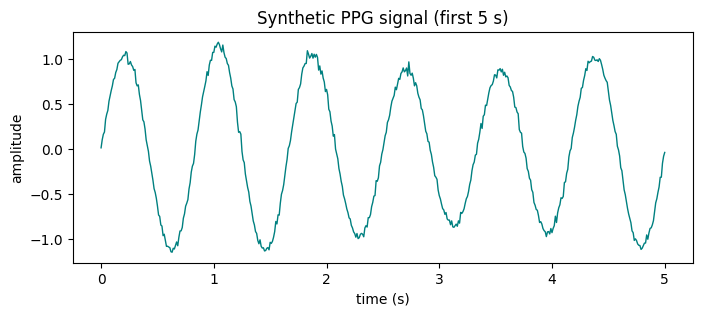

In [18]:
# SOLUTION BEGIN
# Solution 16
fig, ax = plt.subplots(figsize=(8, 3))
mask_5s = t <= 5
ax.plot(t[mask_5s], ppg[mask_5s], lw=1.0, color="teal")
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title("Synthetic PPG signal (first 5 s)")
plt.show()
# SOLUTION END



**Exercise 17 — Scatter plot coloured by category.** Using `cohort`, make a scatter plot of `bmi`
(x-axis) vs. `systolic_bp` (y-axis), with points **coloured by `diagnosis`** (three colours) and a
legend identifying each colour.

> 🤖 *Gemini tip:* "Write matplotlib code for a scatter plot where points are coloured according to a
> categorical column, with a legend."


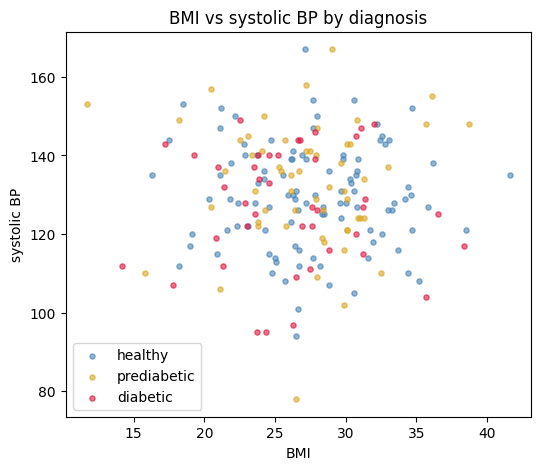

In [19]:
# SOLUTION BEGIN
# Solution 17
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"healthy": "steelblue", "prediabetic": "goldenrod", "diabetic": "crimson"}
for dx, col in colors.items():
    m = cohort["diagnosis"] == dx
    ax.scatter(cohort.loc[m, "bmi"], cohort.loc[m, "systolic_bp"], s=14, alpha=0.6, color=col, label=dx)
ax.set_xlabel("BMI"); ax.set_ylabel("systolic BP"); ax.set_title("BMI vs systolic BP by diagnosis")
ax.legend()
plt.show()
# SOLUTION END



**Exercise 18 — Histogram + bar chart.** Make two panels side by side (`plt.subplots(1, 2, ...)`):
(left) an **overlaid histogram** of `glucose`, one colour per `diagnosis`, with a legend; (right) a
**bar chart** of `cohort["diagnosis"].value_counts()`.

> 🤖 *Gemini tip:* "Show me matplotlib code for two side-by-side subplots: an overlaid histogram by
> category on the left, and a bar chart of category counts on the right."


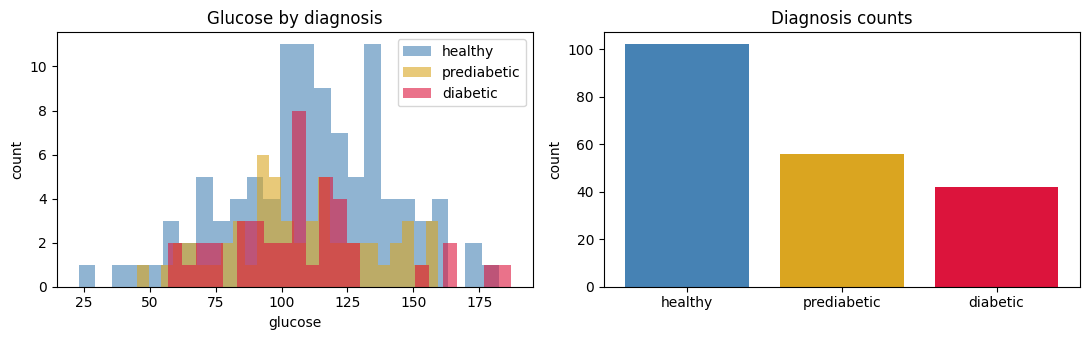

In [20]:
# SOLUTION BEGIN
# Solution 18
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
colors = {"healthy": "steelblue", "prediabetic": "goldenrod", "diabetic": "crimson"}
for dx, col in colors.items():
    axes[0].hist(cohort.loc[cohort["diagnosis"] == dx, "glucose"], bins=25, alpha=0.6, color=col, label=dx)
axes[0].set_xlabel("glucose"); axes[0].set_ylabel("count")
axes[0].set_title("Glucose by diagnosis"); axes[0].legend()

counts = cohort["diagnosis"].value_counts()
axes[1].bar(counts.index, counts.values, color=[colors[d] for d in counts.index])
axes[1].set_ylabel("count"); axes[1].set_title("Diagnosis counts")
plt.tight_layout(); plt.show()
# SOLUTION END



**Exercise 19 — A 2×2 grid of histograms.** Using `plt.subplots(2, 2, ...)`, plot a histogram of
`age`, `bmi`, `systolic_bp` and `glucose`, one per panel, each with its own title.

> 🤖 *Gemini tip:* "Write matplotlib code for a 2x2 grid of subplots, each showing a histogram of a
> different pandas column, looping over the axes array."


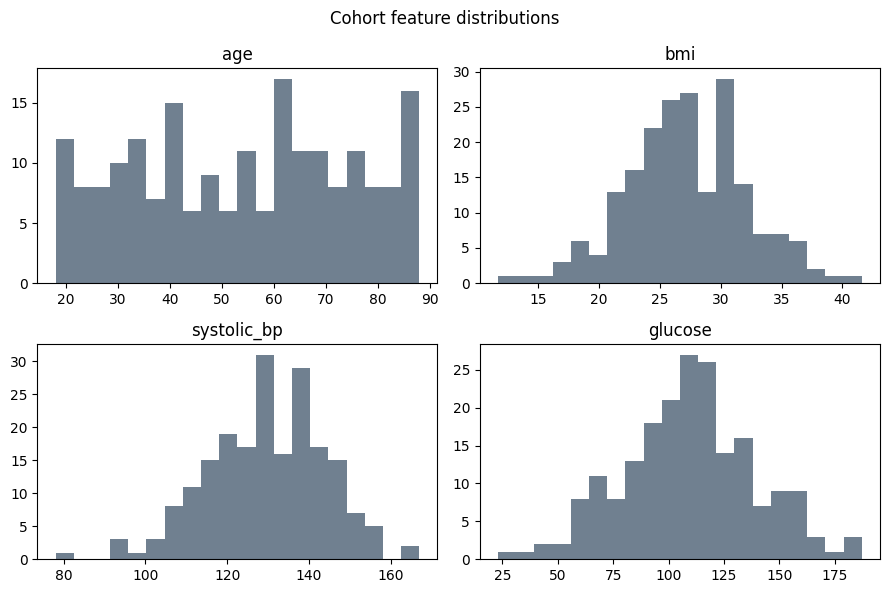

In [21]:
# SOLUTION BEGIN
# Solution 19
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
cols = ["age", "bmi", "systolic_bp", "glucose"]
for ax, col in zip(axes.ravel(), cols):
    ax.hist(cohort[col], bins=20, color="slategray")
    ax.set_title(col)
fig.suptitle("Cohort feature distributions")
plt.tight_layout(); plt.show()
# SOLUTION END



**Exercise 20 — Pandas' plotting shortcut + annotation + saving.** Recreate the `bmi` histogram using
the **Pandas shortcut** `cohort["bmi"].plot.hist(...)` instead of calling Matplotlib directly. Add a
vertical dashed line at the mean `bmi` (`ax.axvline(...)`) with a text annotation showing its value,
and save the figure to a file with `savefig(...)`.

> 🤖 *Gemini tip:* "Using pandas' .plot.hist() shortcut, how do I then add a vertical line at the mean
> and a text label, and save the figure as a PNG?"


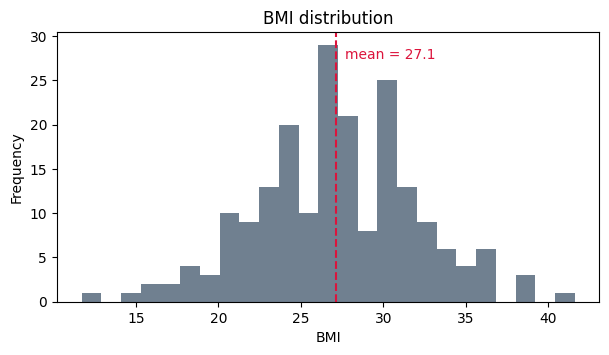

saved bmi_histogram.png


In [22]:
# SOLUTION BEGIN
# Solution 20
ax = cohort["bmi"].plot.hist(bins=25, color="slategray", figsize=(7, 3.5), title="BMI distribution")
mean_bmi = cohort["bmi"].mean()
ax.axvline(mean_bmi, color="crimson", ls="--")
ax.text(mean_bmi + 0.5, ax.get_ylim()[1] * 0.9, f"mean = {mean_bmi:.1f}", color="crimson")
ax.set_xlabel("BMI")
fig = ax.get_figure()
fig.savefig("bmi_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved bmi_histogram.png")
# SOLUTION END



---
## Capstone — one pipeline, all four skills

**Exercise 21 (Capstone).** Write a function

```python
def prepare_and_summarize(df):
    ...
```

that chains everything in this notebook into a single, robust mini-pipeline on `cohort`:

1. **(Python)** wrap the cleaning steps in `try`/`except` so that a missing/renamed column produces a
   clear message instead of crashing the whole function;
2. **(Pandas)** work on a copy of `df`; fill any missing `glucose` values with the median, and add the
   `bmi_class` column from Exercise 13;
3. **(NumPy)** standardise `age`, `bmi`, `systolic_bp` and `glucose` into an array `X_scaled` using
   broadcasting (mean 0, std 1 per column);
4. **(Pandas)** build and return a `groupby("diagnosis")` summary table (count, mean `age`, mean
   `bmi`, mean `glucose`);
5. **(Matplotlib)** produce **one** figure of your choice that best communicates a relationship in the
   data (e.g. the scatter from Exercise 17, or the grid from Exercise 19).

Call `prepare_and_summarize(cohort)` and check that the printed summary table and the figure both make
sense together.

> 🤖 *Gemini tip:* This one is worth doing in stages — ask Gemini to help with **one step at a time**
> ("write the standardisation step using NumPy broadcasting inside a function that already has a
> cleaned DataFrame `df`"), rather than the whole function at once. Read every suggestion before
> pasting it in.


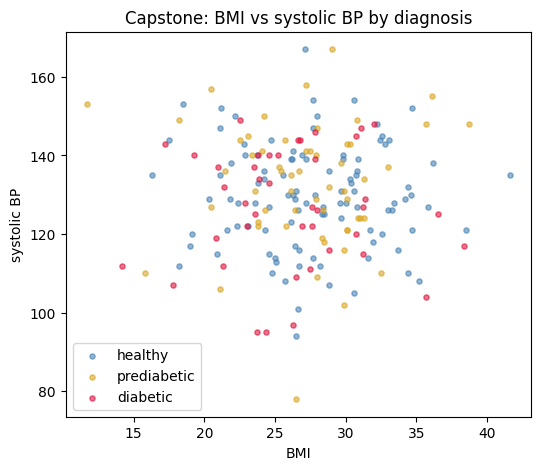

X_scaled shape: (200, 4) | means (~0): [-0. -0. -0. -0.] | stds (~1): [1. 1. 1. 1.]


,n,mean_age,mean_bmi,mean_glucose
diagnosis,,,,
diabetic,42,52.0,26.1,107.7
healthy,102,54.4,27.6,111.4
prediabetic,56,53.5,27.0,107.0


In [23]:
def prepare_and_summarize(df):
    """Clean, standardise, summarise and plot the cohort — the five steps of Exercise 21."""
# SOLUTION BEGIN
    # Solution 21 (Capstone)
    # 1+2 (Python + Pandas): clean defensively, on a copy
    try:
        d = df.copy()
        d["glucose"] = d["glucose"].fillna(d["glucose"].median())

        def classify_bmi(b):
            if b < 18.5:
                return "underweight"
            elif b < 25:
                return "normal"
            elif b < 30:
                return "overweight"
            return "obese"
        d["bmi_class"] = d["bmi"].apply(classify_bmi)

        # 3 (NumPy): standardise via broadcasting
        num_cols = ["age", "bmi", "systolic_bp", "glucose"]
        X = d[num_cols].to_numpy(dtype=float)
        X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    except KeyError as e:
        print("prepare_and_summarize: missing expected column:", e)
        return None

    # 4 (Pandas): per-diagnosis summary
    summary_table = d.groupby("diagnosis").agg(
        n=("patient_id", "size"),
        mean_age=("age", "mean"),
        mean_bmi=("bmi", "mean"),
        mean_glucose=("glucose", "mean"),
    ).round(1)

    # 5 (Matplotlib): one figure
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = {"healthy": "steelblue", "prediabetic": "goldenrod", "diabetic": "crimson"}
    for dx, col in colors.items():
        m = d["diagnosis"] == dx
        ax.scatter(d.loc[m, "bmi"], d.loc[m, "systolic_bp"], s=14, alpha=0.6, color=col, label=dx)
    ax.set_xlabel("BMI"); ax.set_ylabel("systolic BP")
    ax.set_title("Capstone: BMI vs systolic BP by diagnosis")
    ax.legend()
    plt.show()

    print("X_scaled shape:", X_scaled.shape,
          "| means (~0):", np.round(X_scaled.mean(axis=0), 6),
          "| stds (~1):", np.round(X_scaled.std(axis=0), 3))

    return summary_table
# SOLUTION END

summary = prepare_and_summarize(cohort)
summary


---
### End of Module 1 practice
If several exercises in one section felt hard, that section's original notebook (1, 2, 3 or 4) is the
place to go back and re-read before the next session.
